# NCEAS Reproducibility

This notebook reproduces the Shepard Diagram figures from our final report. These figures show how well each dimensionality reduction method preserves pairwise distances from the original embedding space.

## 1. Installation

Full installation instructions are in [INSTALL.md](INSTALL.md). This includes steps to clone the repository, set up the conda environment (`phate-env`), and download the benchmark datasets.

This notebook requires the `phate-env` conda environment to be active:

```bash
conda activate phate-env
jupyter notebook
```

## 2. Data

This project uses five benchmark datasets. See [INSTALL.md](INSTALL.md) for full download instructions.

- **RCV1** (Reuters news hierarchies): `src/data/rcv1/rcv1.csv`
- **arXiv** (30k scientific abstracts): `src/data/arxiv/arxiv_clean.csv`
- **Amazon** (product categories): `src/data/amazon/train_40k.csv`, `src/data/amazon/val_10k.csv`
- **DBpedia**: `src/data/dbpedia/DBPEDIA_test.csv`
- **Web of Science**: `src/data/WebOfScience/Data.xlsx`

Initialize the data folders:

```bash
mkdir -p src/data/arxiv src/data/amazon src/data/dbpedia src/data/WebOfScience src/data/rcv1
```

### Intermediate Embeddings

Generating embeddings takes significant time. To skip this step, download the precomputed embedding files from the NCEAS Teams Data folder:

- `sentence-transformers.zip`: contains `all-MiniLM-L6-v2` embeddings, reduced embeddings, labels, and results
- `Qwen.zip`: contains `Qwen3-Embedding-0.6B` embeddings, reduced embeddings, labels, and results

Extract both zip files and place them under `src/` as follows:

```
src/sentence-transformers/all-MiniLM-L6-v2_embeddings/
src/sentence-transformers/all-MiniLM-L6-v2_reduced_embeddings/
src/Qwen/Qwen3-Embedding-0.6B_embeddings/
src/Qwen/Qwen3-Embedding-0.6B_reduced_embeddings/
```

To generate embeddings and reduced embeddings from scratch, run:

```bash
python src/run_models/benchmark_datasets/eval_pipeline.py --dataset rcv1
```

This will save reduced embeddings to `src/sentence-transformers/all-MiniLM-L6-v2_reduced_embeddings/`.

## 3. Shepard Diagrams

Shepard Diagrams compare pairwise distances in the original high-dimensional space against the reduced space. Points close to the red diagonal indicate better global distance preservation.

We use this to compare PCA, UMAP, PHATE, and PaCMAP on the RCV1 dataset with `all-MiniLM-L6-v2` embeddings. These figures are used in our project report.

In [1]:
import os
import sys

# Navigate to src/ directory (safe to re-run)
repo_root = os.path.abspath('.')
if os.path.basename(repo_root) == 'src':
    src_dir = repo_root
else:
    src_dir = os.path.join(repo_root, 'src')
os.chdir(src_dir)
sys.path.insert(0, src_dir)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import pairwise_distances

In [2]:
def plot_shepard(x_high, x_low, name, sample_size=500):
    indices = np.random.choice(len(x_high), sample_size, replace=False)

    d_high = pairwise_distances(x_high[indices]).flatten()
    d_low = pairwise_distances(x_low[indices]).flatten()

    # normalize to [0, 1] for fair comparison
    d_high = d_high / np.max(d_high)
    d_low = d_low / np.max(d_low)

    plt.figure(figsize=(6, 6))
    plt.scatter(d_high, d_low, alpha=0.1, s=1, color='teal')
    plt.plot([0, 1], [0, 1], color='red', linestyle='--', alpha=0.5)
    plt.title(f"Shepard Diagram: {name}")
    plt.xlabel("High-Dimensional Distance (Normalized)")
    plt.ylabel("Low-Dimensional Distance (Normalized)")
    plt.tight_layout()

    filename = f"shepard_{name.lower()}.png"
    plt.savefig(filename, dpi=300)
    plt.show()
    return filename

In [3]:
embedding_model = "sentence-transformers/all-MiniLM-L6-v2"
reduction_dir = f"{embedding_model}_reduced_embeddings"

# load precomputed reduced embeddings for each method
reductions = {
    "PCA":    np.load(f"{reduction_dir}/PCA_rcv1.npy"),
    "UMAP":   np.load(f"{reduction_dir}/UMAP_rcv1.npy"),
    "PHATE":  np.load(f"{reduction_dir}/PHATE_rcv1.npy"),
    "PaCMAP": np.load(f"{reduction_dir}/PaCMAP_rcv1.npy"),
}

# original high-dimensional embeddings (used as reference for distance comparison)
x_high = np.load(f"{embedding_model}_embeddings/rcv1.npy")
print(x_high.shape)

(1566, 384)


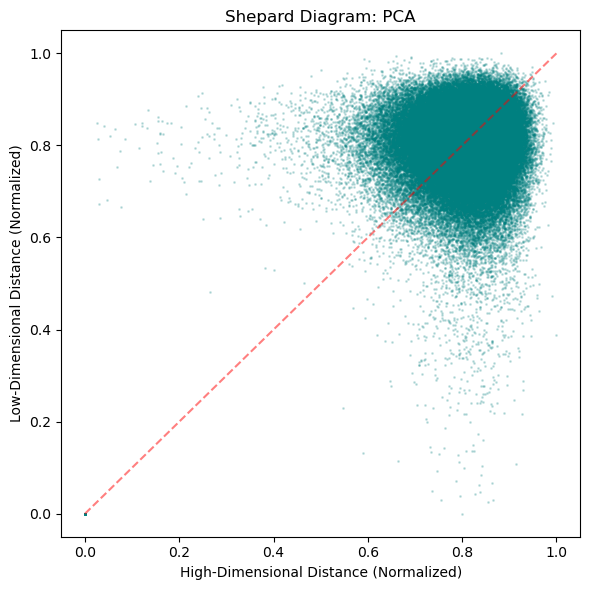

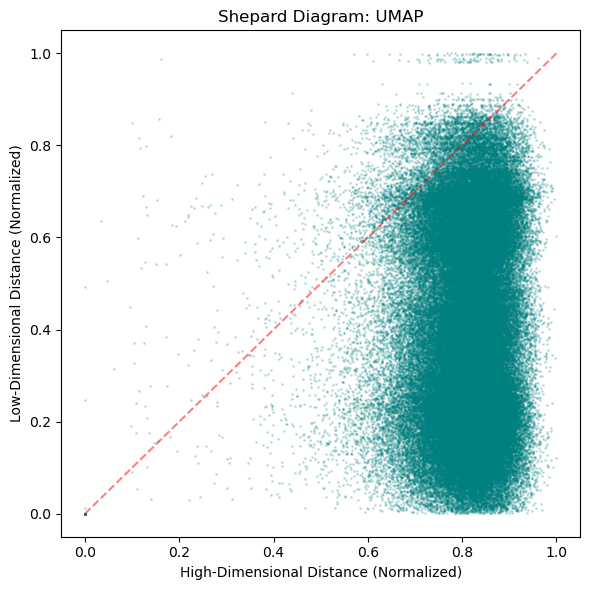

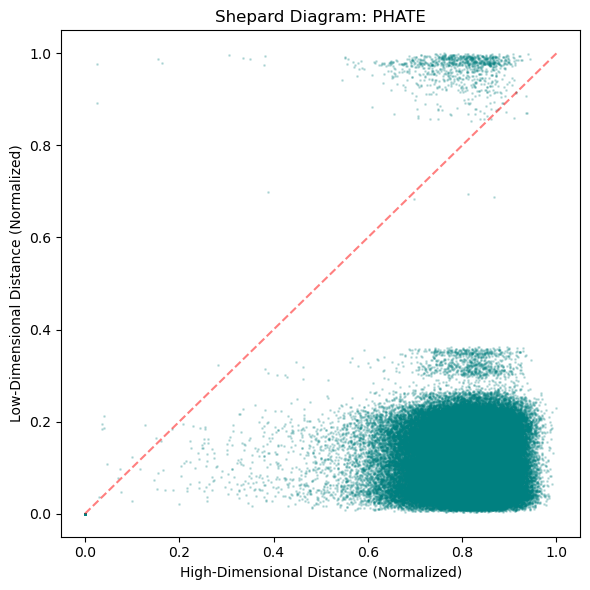

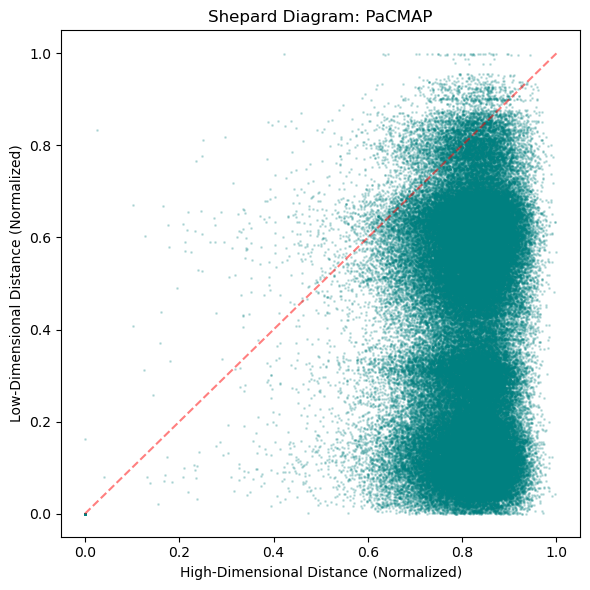

In [4]:
# generate and save shepard diagrams for all four methods
for name, x_low in reductions.items():
    plot_shepard(x_high, x_low, name)

## 4. Interpreting the Results

Points closer to the red diagonal mean the method better preserves global distances. PCA is linear so it compresses distances differently than non-linear methods. PHATE and PaCMAP capture more structure, which shows up as tighter clustering around the diagonal in the mid-range distances.